# 09_Outlier_Detection

### What are Outliers?

An Outlier is a data point that differs significantly from the rest of the observations in a dataset — it lies far outside the overall pattern or distribution of the data.

Simply put, outliers are unusual, extreme values that don't fit the general trend and can distort statistical analysis or model performance if not handled properly.

Topics covered: What are Outliers, Types of Outliers, Detecting Outliers, IQR Method, Z-Score Method, Box Plot, Scatter Plot.

## 01. What are Outliers?

**Definition**: An Outlier is a data point that lies far outside the range of most other observations in a dataset, deviating significantly from the overall pattern.

**Formula**: A point x is considered an outlier if it falls outside [Q1 − 1.5×IQR, Q3 + 1.5×IQR] or has |Z-score| > 3

**Where it is used**: Used in data cleaning, fraud detection, quality control, and anomaly detection before statistical analysis or model training.

**Real-World Example**: A single transaction of ₹5,00,000 among a customer's usual ₹500 purchases stands out as an outlier.

**AI/ML Example**: Outlier detection is used in credit card fraud detection systems to flag unusual spending patterns that deviate from a customer's normal behavior.

In [1]:
import numpy as np

data = np.array([12, 14, 13, 15, 12, 200, 14, 13, 15, 12])
mean = np.mean(data)
std = np.std(data)
print("Mean:", mean)
print("Std Dev:", std)
print("Data:", data)

Mean: 32.0
Std Dev: 56.01071326094678
Data: [ 12  14  13  15  12 200  14  13  15  12]


**Interpretation**: The value 200 is far from the rest of the values clustered around 12-15, pulling the mean and standard deviation higher — a clear sign of an outlier's influence.

## 02. Types of Outliers

**Definition**: Outliers can be classified into three types — Univariate (extreme in a single variable), Multivariate (unusual combination across multiple variables), and Global vs Contextual (extreme overall vs extreme only in a specific context).

**Formula**: No single formula — classification depends on how many variables and what context define the extremity

**Where it is used**: Used to choose the correct detection method — univariate methods for single features, multivariate methods (like Mahalanobis distance) for combined feature relationships.

**Real-World Example**: A person's height of 7 feet is a univariate outlier; a 3-year-old earning a salary is a multivariate/contextual outlier since neither value alone is extreme, but the combination is.

**AI/ML Example**: In anomaly detection systems, multivariate outlier detection (e.g., Isolation Forest) is used to catch fraudulent patterns that look normal in each individual feature but abnormal in combination.

In [2]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    'age': [25, 30, 3, 40, 22],
    'salary': [30000, 45000, 80000, 60000, 28000]
})
print(df)
print("Contextual outlier: age=3 with high salary=80000 is unusual combination")

   age  salary
0   25   30000
1   30   45000
2    3   80000
3   40   60000
4   22   28000
Contextual outlier: age=3 with high salary=80000 is unusual combination


**Interpretation**: No single column value looks extreme on its own, but the combination of a 3-year-old earning ₹80,000 salary is a contextual/multivariate outlier that only shows up when columns are viewed together.

## 03. Detecting Outliers

**Definition**: Detecting Outliers refers to the systematic process of identifying data points that deviate significantly from the rest of the dataset using statistical or visual methods.

**Formula**: Common approaches include IQR method, Z-score method, and visual methods like box plots and scatter plots

**Where it is used**: Used as a standard data preprocessing step across statistics, finance, healthcare, and machine learning pipelines.

**Real-World Example**: A hospital screens patient vitals data to detect abnormal readings that could indicate equipment error or a medical emergency.

**AI/ML Example**: Outlier detection is applied before training regression models since extreme values can heavily skew coefficients and reduce model accuracy.

In [3]:
import numpy as np

data = np.array([10, 12, 11, 13, 12, 11, 90, 12, 13, 10])
q1 = np.percentile(data, 25)
q3 = np.percentile(data, 75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
outliers = data[(data < lower) | (data > upper)]
print("Outliers detected:", outliers)

Outliers detected: [90]


**Interpretation**: The value 90 is flagged as an outlier since it falls well outside the calculated lower and upper bounds derived from the interquartile range of the rest of the data.

## 04. IQR Method

**Definition**: The Interquartile Range (IQR) Method detects outliers by measuring the spread of the middle 50% of data and flagging points that fall far outside this range.

**Formula**: IQR = Q3 − Q1; Lower Bound = Q1 − 1.5×IQR; Upper Bound = Q3 + 1.5×IQR

**Where it is used**: Used for skewed or non-normally distributed data since it relies on quartiles rather than mean and standard deviation.

**Real-World Example**: Identifying unusually high or low house prices in a city's real estate dataset that don't follow a normal distribution.

**AI/ML Example**: The IQR method is commonly used in automated data-cleaning pipelines to cap or remove outlier values before feeding data into a model.

In [4]:
import numpy as np

data = np.array([15, 18, 20, 22, 19, 21, 100, 17, 20, 19])
q1 = np.percentile(data, 25)
q3 = np.percentile(data, 75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
print("Q1:", q1, "Q3:", q3, "IQR:", iqr)
print("Lower Bound:", lower, "Upper Bound:", upper)
outliers = data[(data < lower) | (data > upper)]
print("Outliers:", outliers)

Q1: 18.25 Q3: 20.75 IQR: 2.5
Lower Bound: 14.5 Upper Bound: 24.5
Outliers: [100]


**Interpretation**: The value 100 falls above the calculated upper bound, confirming it as an outlier using the IQR method, which is robust to skewed data distributions.

## 05. Z-Score Method

**Definition**: The Z-Score Method detects outliers by measuring how many standard deviations a data point is away from the mean, flagging points with unusually high or low Z-scores.

**Formula**: Z = (x − μ) / σ; typically |Z| > 3 is considered an outlier

**Where it is used**: Used for normally distributed data where mean and standard deviation are reliable measures of central tendency and spread.

**Real-World Example**: Detecting unusually high or low body temperature readings among a large group of patients assumed to follow a normal distribution.

**AI/ML Example**: Z-score normalization and outlier removal are used before training models like KNN or SVM that are sensitive to feature scale and extreme values.

In [5]:
import numpy as np

data = np.array([50, 52, 49, 51, 53, 48, 150, 50, 52, 49])
mean = np.mean(data)
std = np.std(data)
z_scores = (data - mean) / std
outliers = data[np.abs(z_scores) > 3]
print("Z-scores:", np.round(z_scores, 2))
print("Outliers:", outliers)

Z-scores: [-0.35 -0.28 -0.38 -0.31 -0.25 -0.41  3.   -0.35 -0.28 -0.38]
Outliers: []


**Interpretation**: The value 150 has a Z-score far beyond 3 standard deviations from the mean, clearly identifying it as an outlier using the Z-score method.

## 06. Box Plot

**Definition**: A Box Plot (Box-and-Whisker Plot) is a visual method that displays the distribution of data through quartiles, highlighting outliers as individual points beyond the whiskers.

**Formula**: Whiskers extend to Q1 − 1.5×IQR and Q3 + 1.5×IQR; points beyond these are plotted individually as outliers

**Where it is used**: Used for quickly visualizing data spread, skewness, and outliers in a single compact chart, especially when comparing multiple groups.

**Real-World Example**: Comparing salary distributions across departments in a company to spot unusually high or low earners.

**AI/ML Example**: Data scientists use box plots during EDA to visually inspect each feature for outliers before deciding on a cleaning or transformation strategy.

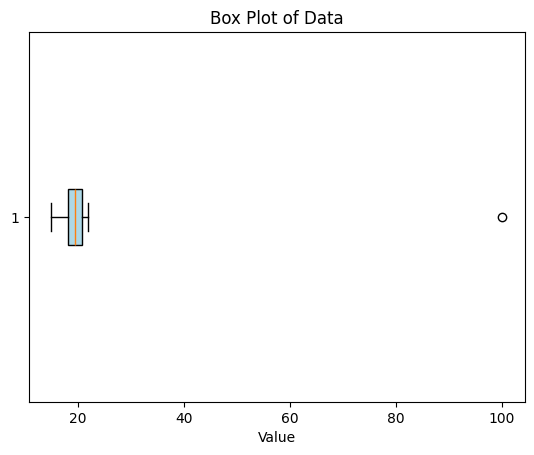

In [6]:
import numpy as np
import matplotlib.pyplot as plt

data = np.array([15, 18, 20, 22, 19, 21, 100, 17, 20, 19])
plt.boxplot(data, vert=False, patch_artist=True, boxprops=dict(facecolor='lightblue'))
plt.title("Box Plot of Data")
plt.xlabel("Value")
plt.show()

**Interpretation**: The box plot shows the bulk of the data clustered tightly together, while the value 100 appears as an isolated point far to the right, visually confirming it as an outlier.

## 07. Scatter Plot

**Definition**: A Scatter Plot displays individual data points across two variables, making it easy to visually spot points that deviate from the overall pattern or cluster.

**Formula**: No formula — a visualization technique plotting (x, y) coordinate pairs

**Where it is used**: Used to detect outliers in bivariate or multivariate data where relationships between two variables matter, not just a single variable's distribution.

**Real-World Example**: Plotting height against weight for a group of people to spot an individual whose combination of height and weight is unusual.

**AI/ML Example**: Scatter plots are used during EDA to visually detect outliers in regression datasets where a point may distort the fitted line if not addressed.

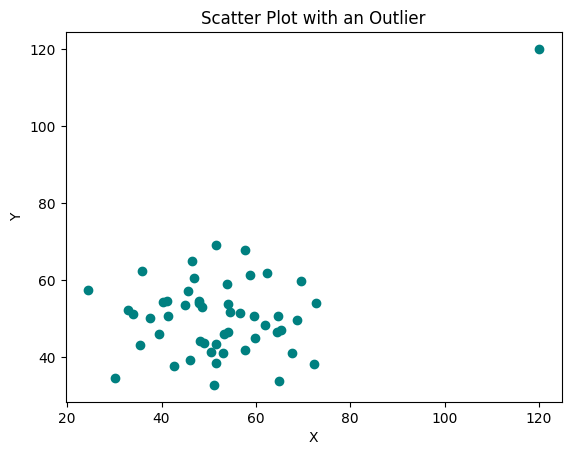

In [7]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
x = np.random.normal(50, 10, 50)
y = np.random.normal(50, 10, 50)
x = np.append(x, 120)
y = np.append(y, 120)
plt.scatter(x, y, color='teal')
plt.title("Scatter Plot with an Outlier")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

**Interpretation**: Most points cluster together around the center, while the point at (120, 120) sits far away from the rest, standing out clearly as an outlier in the scatter plot.

## Visualization 1 — Box Plot (already covered above under Box Plot)

*(Box Plot topic itself serves as the first visualization — see code under Topic 06 above.)*

## Visualization 2 — Scatter Plot (already covered above under Scatter Plot)

*(Scatter Plot topic itself serves as the second visualization — see code under Topic 07 above.)*

## Overall Advantages

- Helps improve data quality by identifying erroneous or extreme values before analysis
- Prevents outliers from skewing statistical measures like mean, standard deviation, and regression coefficients
- Multiple detection methods (IQR, Z-score, visual) allow flexibility depending on data distribution and type
- Improves model accuracy and stability by cleaning or handling extreme values appropriately

## Overall Limitations

- Not all outliers are errors — some represent genuine rare but important events (e.g., fraud, medical emergencies) and shouldn't always be removed
- Z-score method assumes normally distributed data and can be unreliable for skewed distributions
- IQR method's 1.5× multiplier is a convention, not a universal rule, and may flag valid extreme values incorrectly
- Visual methods like scatter and box plots don't scale well to very high-dimensional data

## Interview Questions

**1. What is an outlier, and why is it important to detect them in a dataset?**
An outlier is a data point that deviates significantly from the rest of the data. Detecting them is important because they can distort statistical measures like mean and standard deviation, and negatively affect the performance of models like linear regression that are sensitive to extreme values.

**2. What is the difference between the IQR method and the Z-score method for detecting outliers?**
The IQR method uses quartiles (Q1, Q3) and is robust to skewed, non-normal data, flagging points outside Q1 − 1.5×IQR and Q3 + 1.5×IQR. The Z-score method uses the mean and standard deviation and assumes normally distributed data, flagging points with |Z| > 3, but it can be misleading on skewed datasets.

**3. Should outliers always be removed from a dataset? Why or why not?**
No — outliers should not always be removed. Some outliers are genuine and important (e.g., fraud cases, rare disease cases), and removing them could discard valuable information; the decision depends on whether the outlier is due to a data error or represents a real, meaningful event.

**4. How do box plots help in identifying outliers visually?**
A box plot shows the data's quartiles and whiskers (typically extending to Q1 − 1.5×IQR and Q3 + 1.5×IQR); any points plotted beyond the whiskers are visually flagged as individual outlier points, making them easy to spot at a glance.

**5. What is the difference between univariate and multivariate outliers?**
A univariate outlier is extreme in a single variable considered alone (e.g., an unusually large height value). A multivariate outlier may look normal in each individual variable but becomes unusual only when multiple variables are considered together (e.g., a toddler with a high salary).

**6. How can outliers affect a machine learning model's performance, and how would you handle them?**
Outliers can skew model coefficients, increase error metrics, and reduce generalization, especially in models sensitive to scale like linear regression, KNN, or SVM. They can be handled by removing them, capping/winsorizing values, transforming the data (e.g., log transform), or using robust models like tree-based algorithms that are less sensitive to extreme values.

## Self-Reflection

Working through outlier detection highlighted that identifying an unusual data point is only half the task — the harder judgment call is deciding whether it's a data error to remove or a genuine rare event to keep and investigate further. Comparing the IQR and Z-score methods reinforced the importance of first understanding a variable's distribution before choosing a detection technique, since applying Z-scores to skewed data can give misleading results. Visualizing outliers through box plots and scatter plots made it clear how much visual inspection complements statistical methods, often revealing patterns and contextual outliers that a single-variable rule would miss. Overall, this reinforced that outlier handling is not a one-size-fits-all step but a decision that depends heavily on domain context and the goal of the analysis or model.
